In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import plotly.express as px

import warnings
warnings.filterwarnings("ignore")

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Supply_Chain_Analytics/data/DataCoSupplyChainDataset.csv", encoding="latin1")

In [ ]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Rows: 180519
Columns: 53


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  object 
 9   Customer City                  180519 non-null  object 
 10  Customer Country               180519 non-null  object 
 11  Customer Email                 180519 non-null  object 
 12  Customer Fname                

In [ ]:
missing = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

missing.columns = ["Column", "Missing Values"]

missing.head(30)

,Column,Missing Values
0,Product Description,180519
1,Order Zipcode,155679
2,Customer Lname,8
3,Customer Zipcode,3
4,Days for shipment (scheduled),0
5,Sales per customer,0
6,Benefit per order,0
7,Delivery Status,0
8,Late_delivery_risk,0
9,Customer City,0


In [ ]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [ ]:
df.dtypes

,0
Type,object
Days for shipping (real),int64
Days for shipment (scheduled),int64
Benefit per order,float64
Sales per customer,float64
Delivery Status,object
Late_delivery_risk,int64
Category Id,int64
Category Name,object
Customer City,object


In [ ]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Type,180519,4,DEBIT,69295,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Days for shipping (real),180519.0,NaN,NaN,NaN,3.497654,1.623722,0.0,2.0,3.0,5.0,6.0
Days for shipment (scheduled),180519.0,NaN,NaN,NaN,2.931847,1.374449,0.0,2.0,4.0,4.0,4.0
Benefit per order,180519.0,NaN,NaN,NaN,21.974989,104.433526,-4274.97998,7.0,31.52,64.800003,911.799988
Sales per customer,180519.0,NaN,NaN,NaN,183.107609,120.04367,7.49,104.379997,163.990005,247.399994,1939.98999
Delivery Status,180519,4,Late delivery,98977,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Late_delivery_risk,180519.0,NaN,NaN,NaN,0.548291,0.497664,0.0,0.0,1.0,1.0,1.0
Category Id,180519.0,NaN,NaN,NaN,31.851451,15.640064,2.0,18.0,29.0,45.0,76.0
Category Name,180519,50,Cleats,24551,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer City,180519,563,Caguas,66770,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
for i, col in enumerate(df.columns, start=1):
    print(f"{i}. {col}")

1. Type
2. Days for shipping (real)
3. Days for shipment (scheduled)
4. Benefit per order
5. Sales per customer
6. Delivery Status
7. Late_delivery_risk
8. Category Id
9. Category Name
10. Customer City
11. Customer Country
12. Customer Email
13. Customer Fname
14. Customer Id
15. Customer Lname
16. Customer Password
17. Customer Segment
18. Customer State
19. Customer Street
20. Customer Zipcode
21. Department Id
22. Department Name
23. Latitude
24. Longitude
25. Market
26. Order City
27. Order Country
28. Order Customer Id
29. order date (DateOrders)
30. Order Id
31. Order Item Cardprod Id
32. Order Item Discount
33. Order Item Discount Rate
34. Order Item Id
35. Order Item Product Price
36. Order Item Profit Ratio
37. Order Item Quantity
38. Sales
39. Order Item Total
40. Order Profit Per Order
41. Order Region
42. Order State
43. Order Status
44. Order Zipcode
45. Product Card Id
46. Product Category Id
47. Product Description
48. Product Image
49. Product Name
50. Product Price
51

In [ ]:
df.columns.tolist()

['Type',
 'Days for shipping (real)',
 'Days for shipment (scheduled)',
 'Benefit per order',
 'Sales per customer',
 'Delivery Status',
 'Late_delivery_risk',
 'Category Id',
 'Category Name',
 'Customer City',
 'Customer Country',
 'Customer Email',
 'Customer Fname',
 'Customer Id',
 'Customer Lname',
 'Customer Password',
 'Customer Segment',
 'Customer State',
 'Customer Street',
 'Customer Zipcode',
 'Department Id',
 'Department Name',
 'Latitude',
 'Longitude',
 'Market',
 'Order City',
 'Order Country',
 'Order Customer Id',
 'order date (DateOrders)',
 'Order Id',
 'Order Item Cardprod Id',
 'Order Item Discount',
 'Order Item Discount Rate',
 'Order Item Id',
 'Order Item Product Price',
 'Order Item Profit Ratio',
 'Order Item Quantity',
 'Sales',
 'Order Item Total',
 'Order Profit Per Order',
 'Order Region',
 'Order State',
 'Order Status',
 'Order Zipcode',
 'Product Card Id',
 'Product Category Id',
 'Product Description',
 'Product Image',
 'Product Name',
 'Product P

In [ ]:
df = df.rename(columns={
    'Type':'payment_type',
    'Days for shipping (real)':'actual_shipping_days',
    'Days for shipment (scheduled)':'scheduled_shipping_days',
    'Benefit per order':'benefit_per_order',
    'Sales per customer':'sales_per_customer',
    'Delivery Status':'delivery_status',
    'Late_delivery_risk':'late_delivery_risk',
    'Category Name':'category_name',
    'Customer Segment':'customer_segment',
    'Customer City':'customer_city',
    'Customer State':'customer_state',
    'Customer Country':'customer_country',
    'Department Name':'department_name',
    'Market':'market',
    'Order Country':'order_country',
    'Order Region':'order_region',
    'Order State':'order_state',
    'Order Status':'order_status',
    'Order Id':'order_id',
    'Sales':'sales',
    'Order Profit Per Order':'order_profit',
    'Order Item Quantity':'quantity',
    'Order Item Discount':'discount',
    'Order Item Discount Rate':'discount_rate',
    'Order Item Product Price':'unit_price',
    'Product Name':'product_name',
    'Product Price':'product_price',
    'Shipping Mode':'shipping_mode',
    'order date (DateOrders)':'order_date',
    'shipping date (DateOrders)':'shipping_date'
})

In [ ]:
df['order_date'] = pd.to_datetime(df['order_date'])
df['shipping_date'] = pd.to_datetime(df['shipping_date'])

In [ ]:
df['shipping_delay'] = (
    df['actual_shipping_days']
    - df['scheduled_shipping_days']
)

df['profit_margin'] = (
    df['order_profit']
    / df['sales']
) * 100

In [ ]:
missing = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
)

missing[missing > 0]

,0
Product Description,180519
Order Zipcode,155679
Customer Lname,8
Customer Zipcode,3


**Data** **Cleaning**


In [ ]:
columns_to_drop = [
    "Product Description",
    "Product Image",
    "Customer Password",
    "Customer Email",
    "Customer Street",
    "Latitude",
    "Longitude",
    "Order Zipcode"
]

df = df.drop(columns=columns_to_drop)

In [ ]:
df["Customer Lname"] = df["Customer Lname"].fillna("Unknown")

df["Customer Zipcode"] = df["Customer Zipcode"].fillna(
    df["Customer Zipcode"].mode()[0]
)

In [ ]:
df.isnull().sum().sort_values(ascending=False).head(10)

,0
payment_type,0
actual_shipping_days,0
scheduled_shipping_days,0
benefit_per_order,0
sales_per_customer,0
delivery_status,0
late_delivery_risk,0
Category Id,0
category_name,0
customer_city,0


In [ ]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [ ]:
print(df.shape)

(180519, 47)


**Exploratory_Data_Analysis**

In [ ]:
total_sales = df["sales"].sum()

total_profit = df["order_profit"].sum()

total_orders = df["order_id"].nunique()

total_customers = df["Customer Id"].nunique()

avg_order_value = df["sales"].mean()

late_delivery_rate = (
    df["late_delivery_risk"].mean()*100
)

print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Total Customers: {total_customers:,}")
print(f"Average Order Value: ${avg_order_value:.2f}")
print(f"Late Delivery Risk: {late_delivery_rate:.2f}%")

Total Sales: $36,784,735.01
Total Profit: $3,966,902.97
Total Orders: 65,752
Total Customers: 20,652
Average Order Value: $203.77
Late Delivery Risk: 54.83%


In [ ]:
market_sales = (
    df.groupby("market")["sales"]
      .sum()
      .sort_values(ascending=False)
)

market_sales

,sales
market,
Europe,1.087240e+07
LATAM,1.027761e+07
Pacific Asia,8.273744e+06
USCA,5.066529e+06
Africa,2.294453e+06


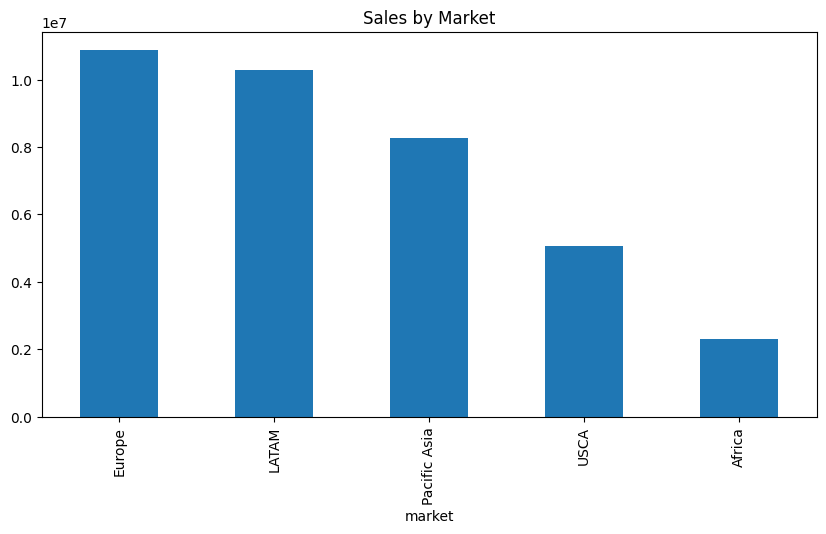

In [ ]:
market_sales.plot(
    kind="bar",
    figsize=(10,5),
    title="Sales by Market"
)

plt.show()

In [ ]:
market_profit = (
    df.groupby("market")["order_profit"]
      .sum()
      .sort_values(ascending=False)
)

market_profit

,order_profit
market,
Europe,1.169443e+06
LATAM,1.123322e+06
Pacific Asia,8.577534e+05
USCA,5.643138e+05
Africa,2.520712e+05


In [ ]:
df["shipping_mode"].value_counts()

,count
shipping_mode,
Standard Class,107752
Second Class,35216
First Class,27814
Same Day,9737


In [ ]:
pd.crosstab(
    df["shipping_mode"],
    df["delivery_status"]
)

delivery_status,Advance shipping,Late delivery,Shipping canceled,Shipping on time
shipping_mode,,,,
First Class,0,26513,1301,0
Same Day,0,4454,444,4839
Second Class,0,26987,1410,6819
Standard Class,41592,41023,4599,20538


In [ ]:
category_sales = (
    df.groupby("category_name")["sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

category_sales

,sales
category_name,
Fishing,6.929654e+06
Cleats,4.431943e+06
Camping & Hiking,4.118426e+06
Cardio Equipment,3.694843e+06
Women's Apparel,3.147800e+06
Water Sports,3.113845e+06
Men's Footwear,2.891758e+06
Indoor/Outdoor Games,2.888994e+06
Shop By Sport,1.309522e+06


In [ ]:
category_profit = (
    df.groupby("category_name")["order_profit"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

category_profit

,order_profit
category_name,
Fishing,756220.767190
Cleats,494636.919791
Camping & Hiking,427455.568106
Cardio Equipment,383011.098485
Women's Apparel,350421.029567
Water Sports,325146.960038
Indoor/Outdoor Games,318451.430554
Men's Footwear,311902.820214
Shop By Sport,129813.960315


In [ ]:
segment_sales = (
    df.groupby("customer_segment")["sales"]
      .sum()
      .sort_values(ascending=False)
)

segment_sales

,sales
customer_segment,
Consumer,1.909579e+07
Corporate,1.116841e+07
Home Office,6.520538e+06


In [ ]:
country_sales = (
    df.groupby("order_country")["sales"]
      .sum()
      .sort_values(ascending=False)
      .head(20)
)

country_sales

,sales
order_country,
Estados Unidos,4.879668e+06
Francia,2.879942e+06
México,2.633195e+06
Alemania,2.074172e+06
Australia,1.694622e+06
Reino Unido,1.612095e+06
Brasil,1.594320e+06
China,1.172902e+06
Italia,1.072182e+06


**Business_Problem_Analysis**

Business Question 1: Which shipping mode has the highest late delivery rate?

In [ ]:
shipping_delay = pd.crosstab(
    df["shipping_mode"],
    df["delivery_status"],
    normalize="index"
) * 100

shipping_delay.round(2)

delivery_status,Advance shipping,Late delivery,Shipping canceled,Shipping on time
shipping_mode,,,,
First Class,0.0,95.32,4.68,0.00
Same Day,0.0,45.74,4.56,49.70
Second Class,0.0,76.63,4.00,19.36
Standard Class,38.6,38.07,4.27,19.06


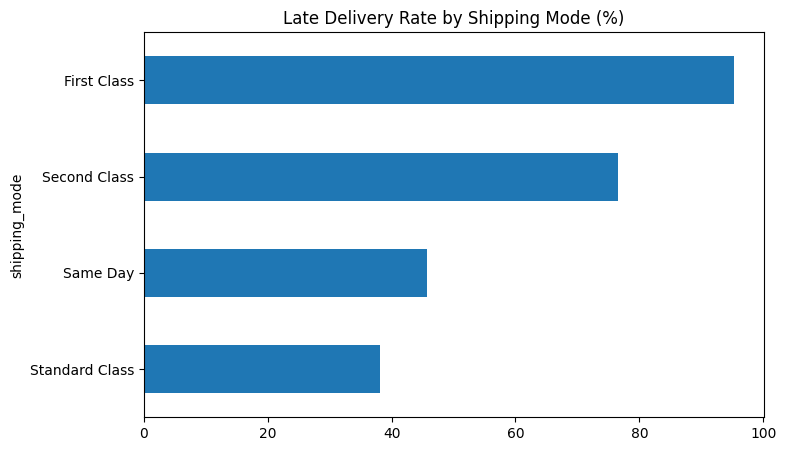

In [ ]:
shipping_delay["Late delivery"].sort_values().plot(
    kind="barh",
    figsize=(8,5),
    title="Late Delivery Rate by Shipping Mode (%)"
)

plt.show()

Business Question 2: Which markets have the highest late delivery risk?

In [ ]:
market_delay = (
    df.groupby("market")["late_delivery_risk"]
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

market_delay

,late_delivery_risk
market,
Europe,55.207753
Pacific Asia,55.046049
USCA,54.800574
Africa,54.589289
LATAM,54.355158


Business Question 3: Which countries have the highest late delivery risk?

In [ ]:
country_delay = (
    df.groupby("order_country")["late_delivery_risk"]
      .mean()
      .mul(100)
      .sort_values(ascending=False)
      .head(20)
)

country_delay

,late_delivery_risk
order_country,
Bután,100.000000
Armenia,100.000000
Guinea Ecuatorial,100.000000
Eritrea,100.000000
República de Gambia,100.000000
Sáhara Occidental,100.000000
Sudán del Sur,100.000000
Suazilandia,100.000000
Laos,100.000000


Business Question 4: Which categories have the lowest profit margin?

In [ ]:
df["profit_margin"] = (
    df["order_profit"] / df["sales"]
) * 100

In [ ]:
margin = (
    df.groupby("category_name")["profit_margin"]
      .mean()
      .sort_values()
)

margin.head(15)

,profit_margin
category_name,
Men's Clothing,4.574068
Strength Training,5.132079
As Seen on TV!,5.500911
Books,7.015031
Video Games,8.158148
Hunting & Shooting,8.245051
DVDs,8.382624
Pet Supplies,8.643654
Health and Beauty,8.949460


Business Question 5: Do discounts reduce profit?

In [ ]:
df[["discount","order_profit"]].corr()

,discount,order_profit
discount,1.000000,0.064756
order_profit,0.064756,1.000000


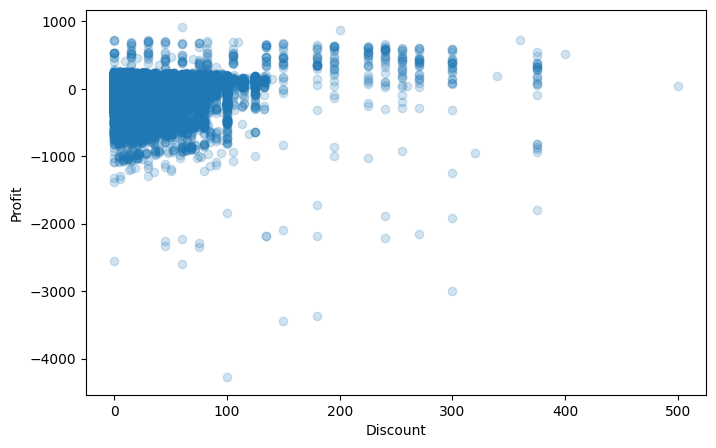

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(
    df["discount"],
    df["order_profit"],
    alpha=0.2
)

plt.xlabel("Discount")
plt.ylabel("Profit")

plt.show()

Business Question 6: Monthly Sales Trend

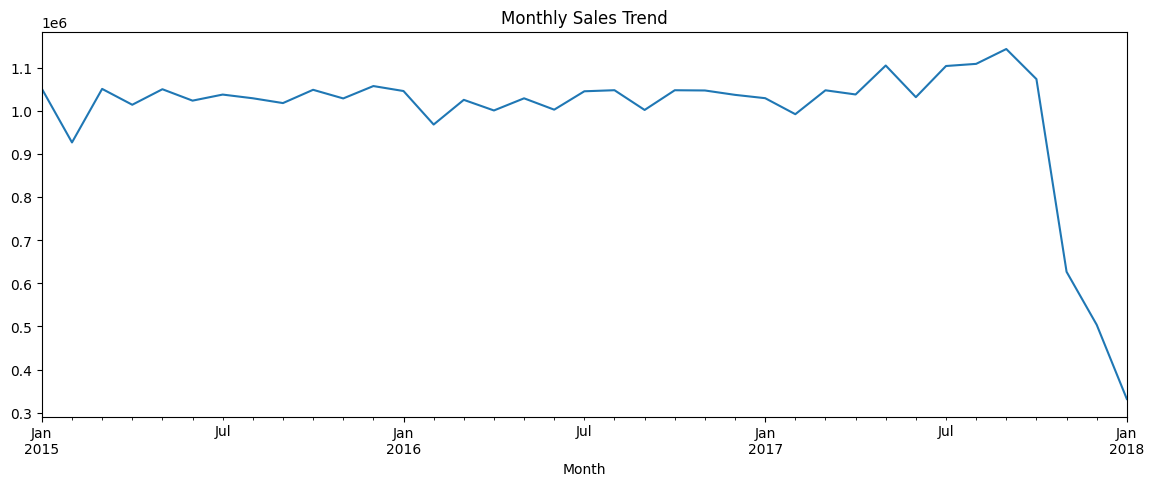

In [ ]:
df["Month"] = df["order_date"].dt.to_period("M")

monthly_sales = (
    df.groupby("Month")["sales"]
      .sum()
)

monthly_sales.plot(
    figsize=(14,5),
    title="Monthly Sales Trend"
)

plt.show()

Business Question 7: Monthly Profit Trend

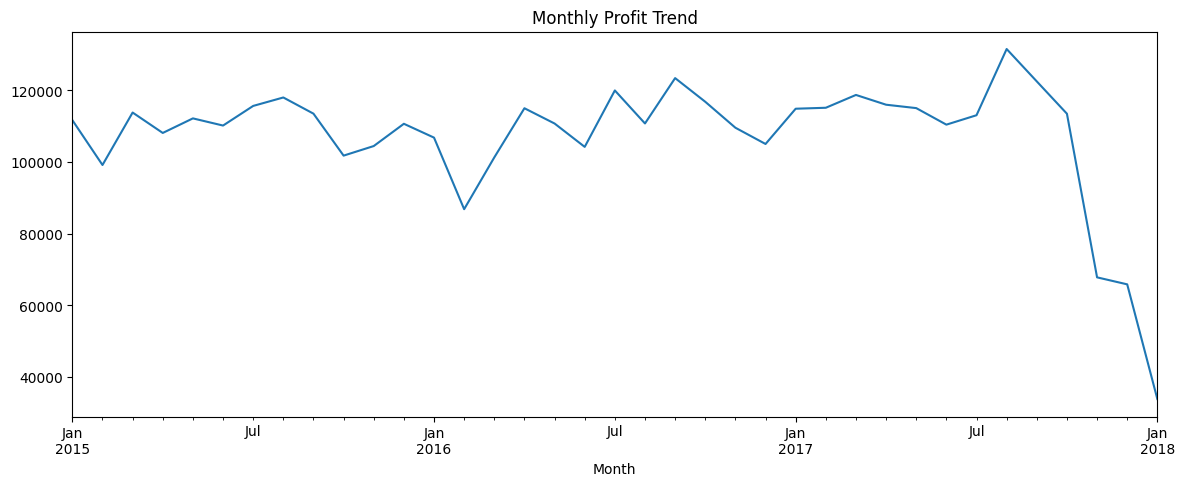

In [ ]:
monthly_profit = (
    df.groupby("Month")["order_profit"]
      .sum()
)

monthly_profit.plot(
    figsize=(14,5),
    title="Monthly Profit Trend"
)

plt.show()

Business Question 8: Top 20 Customers

In [ ]:
top_customers = (
    df.groupby("Customer Id")["sales"]
      .sum()
      .sort_values(ascending=False)
      .head(20)
)

top_customers

,sales
Customer Id,
791,10524.170178
9371,9299.030207
8766,9296.140186
1657,9223.710152
2641,9130.920224
1288,9019.110199
3710,9019.100208
4249,8918.850134
5654,8904.950211


Business Question 9: Pareto Analysis (80/20 Rule)

In [ ]:
customer_sales = (
    df.groupby("Customer Id")["sales"]
      .sum()
      .sort_values(ascending=False)
)

pareto = customer_sales.cumsum() / customer_sales.sum() * 100

pareto.head()

,sales
Customer Id,
791,0.028610
9371,0.053890
8766,0.079161
1657,0.104236
2641,0.129059


Business Question 10: Shipping Delay Distribution

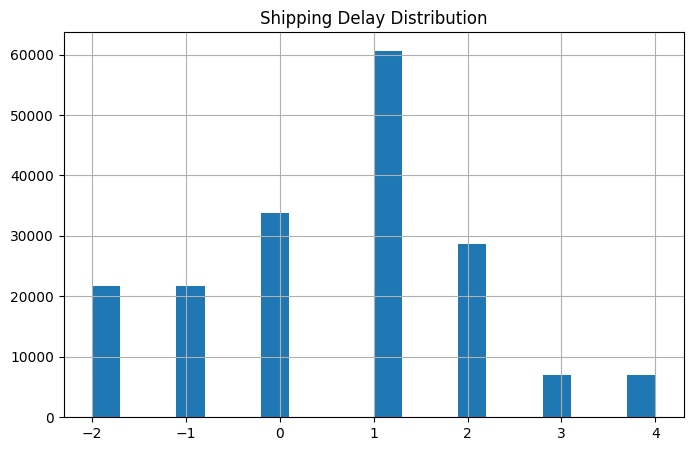

In [ ]:
df["shipping_delay"].hist(
    bins=20,
    figsize=(8,5)
)

plt.title("Shipping Delay Distribution")

plt.show()

**Root Cause Analysis**

Business Question 1:
Which shipping mode generates the highest profit?

In [ ]:
shipping_profit = (
    df.groupby("shipping_mode")
      .agg(
          Sales=("sales","sum"),
          Profit=("order_profit","sum"),
          Orders=("order_id","count")
      )
)

shipping_profit["Profit Margin"] = (
    shipping_profit["Profit"]
    / shipping_profit["Sales"]
)*100

shipping_profit.sort_values(
    "Profit Margin",
    ascending=False
)

,Sales,Profit,Orders,Profit Margin
shipping_mode,,,,
First Class,5.674370e+06,6.431219e+05,27814,11.333804
Standard Class,2.202239e+07,2.370454e+06,107752,10.763837
Second Class,7.145445e+06,7.503082e+05,35216,10.500510
Same Day,1.942529e+06,2.030184e+05,9737,10.451246


Business Question 2:
Which markets have high sales but low profit?

In [ ]:
market_summary = (
    df.groupby("market")
      .agg(
          Sales=("sales","sum"),
          Profit=("order_profit","sum")
      )
)

market_summary["Margin"] = (
    market_summary["Profit"]
    / market_summary["Sales"]
)*100

market_summary

,Sales,Profit,Margin
market,,,
Africa,2.294453e+06,2.520712e+05,10.986113
Europe,1.087240e+07,1.169443e+06,10.756073
LATAM,1.027761e+07,1.123322e+06,10.929791
Pacific Asia,8.273744e+06,8.577534e+05,10.367174
USCA,5.066529e+06,5.643138e+05,11.138075


Business Question 3:
Which customer segment is most profitable?

In [ ]:
segment_profit = (
    df.groupby("customer_segment")
      .agg(
          Sales=("sales","sum"),
          Profit=("order_profit","sum")
      )
)

segment_profit["Margin"] = (
    segment_profit["Profit"]
    / segment_profit["Sales"]
)*100

segment_profit

,Sales,Profit,Margin
customer_segment,,,
Consumer,1.909579e+07,2.073488e+06,10.858350
Corporate,1.116841e+07,1.202575e+06,10.767650
Home Office,6.520538e+06,6.908403e+05,10.594836


Business Question 4:
Top 20 Products

In [ ]:
top_products = (
    df.groupby("product_name")
      .agg(
          Sales=("sales","sum"),
          Profit=("order_profit","sum")
      )
      .sort_values(
          "Sales",
          ascending=False
      )
      .head(20)
)

top_products

,Sales,Profit
product_name,,
Field & Stream Sportsman 16 Gun Fire Safe,6.929654e+06,756220.767190
Perfect Fitness Perfect Rip Deck,4.421143e+06,493828.299782
Diamondback Women's Serene Classic Comfort Bi,4.118426e+06,427455.568106
Nike Men's Free 5.0+ Running Shoe,3.667633e+06,379915.818503
Nike Men's Dri-FIT Victory Golf Polo,3.147800e+06,350421.029567
Pelican Sunstream 100 Kayak,3.099845e+06,324076.370020
Nike Men's CJ Elite 2 TD Football Cleat,2.891758e+06,311902.820214
O'Brien Men's Neoprene Life Vest,2.888994e+06,318451.430554
Under Armour Girls' Toddler Spine Surge Runni,1.269083e+06,126278.510299


Business Question 5:
Which products lose money?

In [ ]:
loss_products = (
    df.groupby("product_name")
      .agg(
          Profit=("order_profit","sum")
      )
      .sort_values("Profit")
      .head(20)
)

loss_products

,Profit
product_name,
SOLE E35 Elliptical,-965.119968
Bushnell Pro X7 Jolt Slope Rangefinder,-255.950003
SOLE E25 Elliptical,-169.559997
GoPro HERO3+ Black Edition Camera,245.630051
Diamondback Girls' Clarity 24 Hybrid Bike 201,284.420003
Polar Loop Activity Tracker,326.200001
Cleveland Golf Women's 588 RTX CB Satin Chrom,370.610006
CDs of rock,383.850000
Garmin Forerunner 910XT GPS Watch,391.129990


Business Question 6:
ABC Inventory Analysis

In [ ]:
product_sales = (
    df.groupby("product_name")["sales"]
      .sum()
      .sort_values(
          ascending=False
      )
      .reset_index()
)

product_sales["Cumulative Sales"] = (
    product_sales["sales"]
      .cumsum()
)

product_sales["Cumulative %"] = (
    product_sales["Cumulative Sales"]
    / product_sales["sales"].sum()
)*100

In [ ]:
def abc(x):

    if x <= 80:
        return "A"

    elif x <=95:
        return "B"

    else:
        return "C"

product_sales["ABC"] = (
    product_sales["Cumulative %"]
    .apply(abc)
)

product_sales.head()

,product_name,sales,Cumulative Sales,Cumulative %,ABC
0,Field & Stream Sportsman 16 Gun Fire Safe,6.929654e+06,6.929654e+06,18.838395,A
1,Perfect Fitness Perfect Rip Deck,4.421143e+06,1.135080e+07,30.857357,A
2,Diamondback Women's Serene Classic Comfort Bi,4.118426e+06,1.546922e+07,42.053375,A
3,Nike Men's Free 5.0+ Running Shoe,3.667633e+06,1.913686e+07,52.023905,A
4,Nike Men's Dri-FIT Victory Golf Polo,3.147800e+06,2.228466e+07,60.581259,A


**Executive Analytics**

Analysis 1: Pareto Analysis (80/20 Rule)

In [ ]:
customer_sales = (
    df.groupby("Customer Id")["sales"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

customer_sales["Cumulative Sales"] = customer_sales["sales"].cumsum()

customer_sales["Cumulative %"] = (
    customer_sales["Cumulative Sales"]
    / customer_sales["sales"].sum()
) * 100

customer_sales.head()

,Customer Id,sales,Cumulative Sales,Cumulative %
0,791,10524.170178,10524.170178,0.028610
1,9371,9299.030207,19823.200384,0.053890
2,8766,9296.140186,29119.340571,0.079161
3,1657,9223.710152,38343.050723,0.104236
4,2641,9130.920224,47473.970946,0.129059


In [ ]:
customers_80 = customer_sales[
    customer_sales["Cumulative %"] <= 80
]

print("Customers contributing 80% revenue:",
      len(customers_80))

print("Total customers:",
      len(customer_sales))

print("Percentage:",
      round(
          len(customers_80)
          / len(customer_sales)
          *100,2
      ),
      "%")

Customers contributing 80% revenue: 8414
Total customers: 20652
Percentage: 40.74 %


Analysis 2: Monthly Business Dashboard

In [ ]:
monthly = (
    df.groupby(df["order_date"].dt.to_period("M"))
      .agg(
          Sales=("sales","sum"),
          Profit=("order_profit","sum"),
          Orders=("order_id","count"),
          Customers=("Customer Id","nunique")
      )
)

monthly

,Sales,Profit,Orders,Customers
order_date,,,,
2015-01,1.051590e+06,111660.740132,5322,1668
2015-02,9.270099e+05,99140.660196,4729,1500
2015-03,1.051254e+06,113778.210191,5362,1654
2015-04,1.014463e+06,108083.679957,5126,1596
2015-05,1.050478e+06,112147.900143,5357,1654
2015-06,1.024006e+06,110147.160313,5134,1616
2015-07,1.038081e+06,115624.059879,5299,1628
2015-08,1.029495e+06,117979.770302,5273,1650
2015-09,1.018339e+06,113467.940118,5140,1608


Analysis 3: Monthly Charts

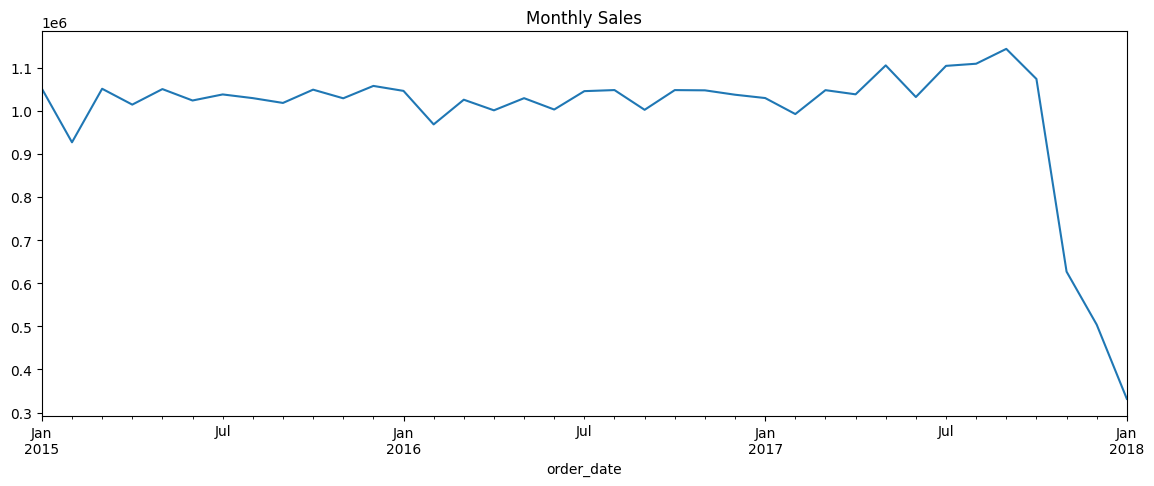

In [ ]:
monthly["Sales"].plot(figsize=(14,5))
plt.title("Monthly Sales")
plt.show()

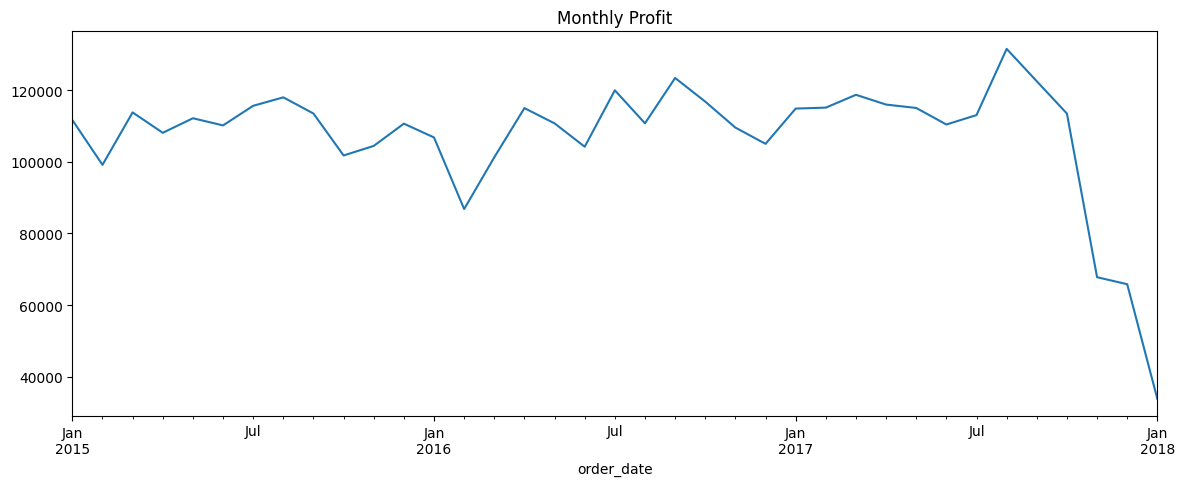

In [ ]:
monthly["Profit"].plot(figsize=(14,5))
plt.title("Monthly Profit")
plt.show()

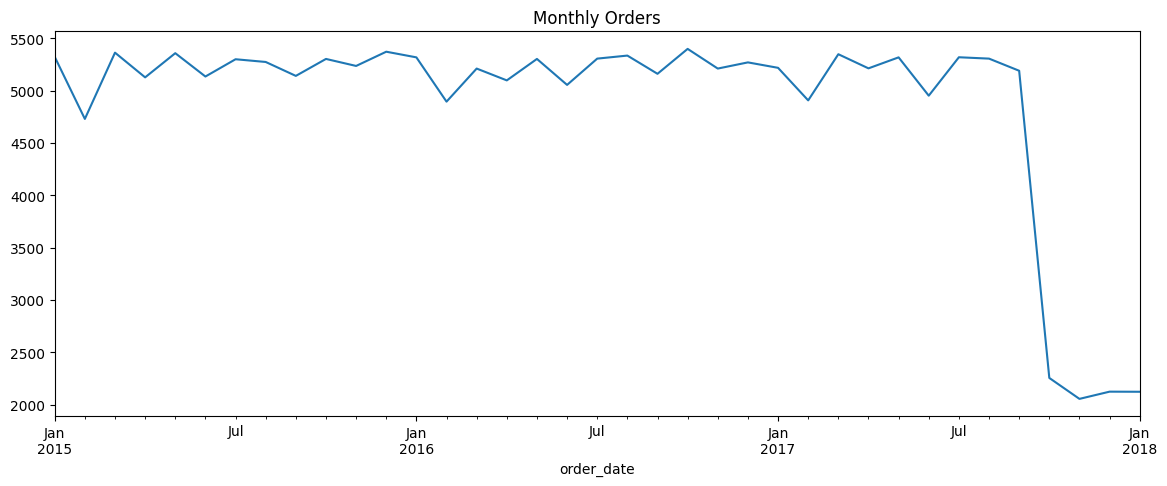

In [ ]:
monthly["Orders"].plot(figsize=(14,5))
plt.title("Monthly Orders")
plt.show()

Analysis 4: Which Categories Need Attention?

In [ ]:
category = (
    df.groupby("category_name")
      .agg(
          Sales=("sales","sum"),
          Profit=("order_profit","sum")
      )
)

category["Margin"] = (
    category["Profit"]
    / category["Sales"]
)*100

category.sort_values(
    "Sales",
    ascending=False
)

,Sales,Profit,Margin
category_name,,,
Fishing,6.929654e+06,756220.767190,10.912822
Cleats,4.431943e+06,494636.919791,11.160724
Camping & Hiking,4.118426e+06,427455.568106,10.379101
Cardio Equipment,3.694843e+06,383011.098485,10.366099
Women's Apparel,3.147800e+06,350421.029567,11.132252
Water Sports,3.113845e+06,325146.960038,10.441977
Men's Footwear,2.891758e+06,311902.820214,10.785925
Indoor/Outdoor Games,2.888994e+06,318451.430554,11.022918
Shop By Sport,1.309522e+06,129813.960315,9.913079


Analysis 5: Top Customers

In [ ]:
top = (
    df.groupby("Customer Id")
      .agg(
          Sales=("sales","sum"),
          Orders=("order_id","count")
      )
      .sort_values(
          "Sales",
          ascending=False
      )
)

top.head(20)

,Sales,Orders
Customer Id,,
791,10524.170178,43
9371,9299.030207,44
8766,9296.140186,38
1657,9223.710152,42
2641,9130.920224,43
1288,9019.110199,42
3710,9019.100208,42
4249,8918.850134,39
5654,8904.950211,47


Analysis 6: Executive KPIs

In [ ]:
print("Revenue")

print(df["sales"].sum())

print("Profit")

print(df["order_profit"].sum())

print("Profit Margin")

print(
    df["order_profit"].sum()
    / df["sales"].sum()
    *100
)

print("Orders")

print(df["order_id"].nunique())

print("Customers")

print(df["Customer Id"].nunique())

print("Average Order Value")

print(df["sales"].mean())

print("Late Delivery Rate")

print(
    df["late_delivery_risk"]
    .mean()*100
)

Revenue
36784735.01337984
Profit
3966902.9740503575
Profit Margin
10.784100993543822
Orders
65752
Customers
20652
Average Order Value
203.77209608617287
Late Delivery Rate
54.82913155955883


In [ ]:
df.to_csv(
    "/content/clean_supply_chain.csv",
    index=False
)

In [ ]:
from google.colab import files
files.download("/content/clean_supply_chain.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
df

,payment_type,actual_shipping_days,scheduled_shipping_days,benefit_per_order,sales_per_customer,delivery_status,late_delivery_risk,Category Id,category_name,customer_city,...,Product Card Id,Product Category Id,product_name,product_price,Product Status,shipping_date,shipping_mode,shipping_delay,profit_margin,Month
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,1360,73,Smart watch,327.750000,0,2018-02-03 22:56:00,Standard Class,-1,27.841342,2018-01
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,1360,73,Smart watch,327.750000,0,2018-01-18 12:27:00,Standard Class,1,-75.999999,2018-01
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,1360,73,Smart watch,327.750000,0,2018-01-17 12:06:00,Standard Class,0,-75.600305,2018-01
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,1360,73,Smart watch,327.750000,0,2018-01-16 11:45:00,Standard Class,-1,6.974829,2018-01
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,1360,73,Smart watch,327.750000,0,2018-01-15 11:24:00,Standard Class,-2,40.948896,2018-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180514,CASH,4,4,40.000000,399.980011,Shipping on time,0,45,Fishing,Brooklyn,...,1004,45,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,2016-01-20 03:40:00,Standard Class,0,10.000500,2016-01
180515,DEBIT,3,2,-613.770019,395.980011,Late delivery,1,45,Fishing,Bakersfield,...,1004,45,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,2016-01-19 01:34:00,Second Class,1,-153.450173,2016-01
180516,TRANSFER,5,4,141.110001,391.980011,Late delivery,1,45,Fishing,Bristol,...,1004,45,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,2016-01-20 21:00:00,Standard Class,1,35.279263,2016-01
180517,PAYMENT,3,4,186.229996,387.980011,Advance shipping,0,45,Fishing,Caguas,...,1004,45,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,2016-01-18 20:18:00,Standard Class,-1,46.559826,2016-01


In [ ]:
df.columns

Index(['payment_type', 'actual_shipping_days', 'scheduled_shipping_days',
       'benefit_per_order', 'sales_per_customer', 'delivery_status',
       'late_delivery_risk', 'Category Id', 'category_name', 'customer_city',
       'customer_country', 'Customer Fname', 'Customer Id', 'Customer Lname',
       'customer_segment', 'customer_state', 'Customer Zipcode',
       'Department Id', 'department_name', 'market', 'Order City',
       'order_country', 'Order Customer Id', 'order_date', 'order_id',
       'Order Item Cardprod Id', 'discount', 'discount_rate', 'Order Item Id',
       'unit_price', 'Order Item Profit Ratio', 'quantity', 'sales',
       'Order Item Total', 'order_profit', 'order_region', 'order_state',
       'order_status', 'Product Card Id', 'Product Category Id',
       'product_name', 'product_price', 'Product Status', 'shipping_date',
       'shipping_mode', 'shipping_delay', 'profit_margin', 'Month'],
      dtype='object')

In [ ]:
df = df.rename(columns={
    "Customer Id": "customer_id",
    "Customer Fname": "customer_fname",
    "Customer Lname": "customer_lname",
    "Customer Zipcode": "customer_zipcode",

    "Category Id": "category_id",

    "Department Id": "department_id",

    "Order City": "order_city",
    "Order Customer Id": "order_customer_id",
    "Order Item Cardprod Id": "order_item_cardprod_id",
    "Order Item Id": "order_item_id",
    "Order Item Profit Ratio": "order_item_profit_ratio",
    "Order Item Total": "order_item_total",

    "Product Card Id": "product_card_id",
    "Product Category Id": "product_category_id",
    "Product Status": "product_status"
})

In [ ]:
df.columns

Index(['payment_type', 'actual_shipping_days', 'scheduled_shipping_days',
       'benefit_per_order', 'sales_per_customer', 'delivery_status',
       'late_delivery_risk', 'category_id', 'category_name', 'customer_city',
       'customer_country', 'customer_fname', 'customer_id', 'customer_lname',
       'customer_segment', 'customer_state', 'customer_zipcode',
       'department_id', 'department_name', 'market', 'order_city',
       'order_country', 'order_customer_id', 'order_date', 'order_id',
       'order_item_cardprod_id', 'discount', 'discount_rate', 'order_item_id',
       'unit_price', 'order_item_profit_ratio', 'quantity', 'sales',
       'order_item_total', 'order_profit', 'order_region', 'order_state',
       'order_status', 'product_card_id', 'product_category_id',
       'product_name', 'product_price', 'product_status', 'shipping_date',
       'shipping_mode', 'shipping_delay', 'profit_margin', 'Month'],
      dtype='object')

In [ ]:
df["Year"] = df["order_date"].dt.year

df["Month_Num"] = df["order_date"].dt.month

df["Quarter"] = df["order_date"].dt.quarter

In [ ]:
column_order = [

    # Date
    "order_date",
    "shipping_date",
    "Year",
    "Quarter",
    "Month",
    "Month_Num",

    # Customer
    "customer_id",
    "customer_fname",
    "customer_lname",
    "customer_segment",
    "customer_city",
    "customer_state",
    "customer_country",
    "customer_zipcode",

    # Product
    "product_name",
    "category_name",
    "department_name",
    "product_price",

    # Order
    "order_id",
    "order_status",
    "quantity",
    "discount",
    "discount_rate",

    # Shipping
    "shipping_mode",
    "delivery_status",
    "actual_shipping_days",
    "scheduled_shipping_days",
    "shipping_delay",
    "late_delivery_risk",

    # Finance
    "sales",
    "sales_per_customer",
    "benefit_per_order",
    "order_profit",
    "profit_margin",

    # Geography
    "market",
    "order_country",
    "order_state",
    "order_region",
    "order_city",

    # Payment
    "payment_type",

    # Remaining IDs
    "category_id",
    "department_id",
    "order_customer_id",
    "order_item_cardprod_id",
    "order_item_id",
    "order_item_profit_ratio",
    "order_item_total",
    "product_card_id",
    "product_category_id",
    "product_status",
    "unit_price"
]

df = df[column_order]

In [ ]:
df["Month"] = df["Month"].dt.strftime("%b")

AttributeError: Can only use .dt accessor with datetimelike values

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 51 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   order_date               180519 non-null  datetime64[ns]
 1   shipping_date            180519 non-null  datetime64[ns]
 2   Year                     180519 non-null  int32         
 3   Quarter                  180519 non-null  int32         
 4   Month                    180519 non-null  period[M]     
 5   Month_Num                180519 non-null  int32         
 6   customer_id              180519 non-null  int64         
 7   customer_fname           180519 non-null  object        
 8   customer_lname           180519 non-null  object        
 9   customer_segment         180519 non-null  object        
 10  customer_city            180519 non-null  object        
 11  customer_state           180519 non-null  object        
 12  customer_country

In [77]:
df.to_csv("clean_supply_chain_powerbi.csv", index=False)